In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
messy_customer_orders_df = pd.read_csv('messy_customer_orders.csv')

In [3]:
messy_customer_orders_df.head()

,order_id,customer_id,region,category,age,income_usd,quantity,unit_price_usd,discount_pct,notes,junk_code
0,100236,1175,West,Sports,55.0,68404.0,1,28.82,10,ok,A0
1,100151,1535,West,Electronics,60.0,57044.0,3,46.39,0,ok,??
2,100329,1038,West,Clothing,15.0,81071.0,1,3.0,10,ok,??
3,100501,1280,North,Electronics,30.0,63320.0,7,50.84,15,ok,??
4,100793,1197,North,Sports,36.0,24502.0,7,27.77,0,manual,Z9


In [4]:
messy_customer_orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 915 entries, 0 to 914
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        915 non-null    int64  
 1   customer_id     915 non-null    int64  
 2   region          915 non-null    object 
 3   category        905 non-null    object 
 4   age             895 non-null    float64
 5   income_usd      899 non-null    object 
 6   quantity        915 non-null    int64  
 7   unit_price_usd  905 non-null    object 
 8   discount_pct    915 non-null    int64  
 9   notes           875 non-null    object 
 10  junk_code       915 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 78.8+ KB


In [5]:
messy_customer_orders_df.isnull()

,order_id,customer_id,region,category,age,income_usd,quantity,unit_price_usd,discount_pct,notes,junk_code
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
910,False,False,False,False,False,False,False,False,False,False,False
911,False,False,False,False,False,False,False,False,False,False,False
912,False,False,False,False,False,False,False,False,False,False,False
913,False,False,False,False,True,False,False,False,False,False,False


In [10]:
messy_customer_orders_df.isna()

,order_id,customer_id,region,category,age,income_usd,quantity,unit_price_usd,discount_pct,notes,junk_code
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
910,False,False,False,False,False,False,False,False,False,False,False
911,False,False,False,False,False,False,False,False,False,False,False
912,False,False,False,False,False,False,False,False,False,False,False
913,False,False,False,False,True,False,False,False,False,False,False


In [11]:
messy_customer_orders_df.notnull()

,order_id,customer_id,region,category,age,income_usd,quantity,unit_price_usd,discount_pct,notes,junk_code
0,True,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...
910,True,True,True,True,True,True,True,True,True,True,True
911,True,True,True,True,True,True,True,True,True,True,True
912,True,True,True,True,True,True,True,True,True,True,True
913,True,True,True,True,False,True,True,True,True,True,True


In [14]:
messy_customer_orders_df.notnull().sum()

order_id          915
customer_id       915
region            915
category          905
age               895
income_usd        899
quantity          915
unit_price_usd    905
discount_pct      915
notes             875
junk_code         915
dtype: int64

In [15]:
messy_customer_orders_df.isna().sum()

order_id           0
customer_id        0
region             0
category          10
age               20
income_usd        16
quantity           0
unit_price_usd    10
discount_pct       0
notes             40
junk_code          0
dtype: int64

In [6]:
messy_customer_orders_df.describe()

,order_id,customer_id,age,quantity,discount_pct
count,915.000000,915.000000,895.000000,915.000000,915.000000
mean,100444.213115,1294.373770,38.474860,4.018579,5.704918
std,261.046378,172.782658,19.886456,2.071132,11.322328
min,100000.000000,1000.000000,-5.000000,-2.000000,0.000000
25%,100213.500000,1150.500000,30.000000,2.000000,0.000000
50%,100442.000000,1293.000000,38.000000,4.000000,5.000000
75%,100670.500000,1441.000000,45.000000,6.000000,10.000000
max,100899.000000,1599.000000,230.000000,7.000000,150.000000


In [16]:
# Turn income_usd and unit_price_usd columns to numeric type
messy_customer_orders_df['income_usd'] = pd.to_numeric(messy_customer_orders_df['income_usd'], errors='coerce')
messy_customer_orders_df['unit_price_usd'] = pd.to_numeric(messy_customer_orders_df['unit_price_usd'], errors='coerce')
messy_customer_orders_df

,order_id,customer_id,region,category,age,income_usd,quantity,unit_price_usd,discount_pct,notes,junk_code
0,100236,1175,West,Sports,55.0,68404.0,1,28.82,10,ok,A0
1,100151,1535,West,Electronics,60.0,57044.0,3,46.39,0,ok,??
2,100329,1038,West,Clothing,15.0,81071.0,1,3.00,10,ok,??
3,100501,1280,North,Electronics,30.0,63320.0,7,50.84,15,ok,??
4,100793,1197,North,Sports,36.0,24502.0,7,27.77,0,manual,Z9
...,...,...,...,...,...,...,...,...,...,...,...
910,100400,1573,North,Grocery,46.0,91419.0,5,NaN,0,ok,A0
911,100118,1394,West,Home,38.0,91451.0,7,65.70,0,ok,X1
912,100701,1258,West,Electronics,40.0,55973.0,2,53.94,10,review,A0
913,100206,1552,East,Grocery,NaN,19926.0,7,56.37,0,ok,A0


In [17]:
messy_customer_orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 915 entries, 0 to 914
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        915 non-null    int64  
 1   customer_id     915 non-null    int64  
 2   region          915 non-null    object 
 3   category        905 non-null    object 
 4   age             895 non-null    float64
 5   income_usd      884 non-null    float64
 6   quantity        915 non-null    int64  
 7   unit_price_usd  891 non-null    float64
 8   discount_pct    915 non-null    int64  
 9   notes           875 non-null    object 
 10  junk_code       915 non-null    object 
dtypes: float64(3), int64(4), object(4)
memory usage: 78.8+ KB


In [18]:
# Replace missing values with their averages
age_avg = messy_customer_orders_df['age'].mean()
income_usd_avg = messy_customer_orders_df['income_usd'].mean()
unit_price_usd_avg = messy_customer_orders_df['unit_price_usd'].mean()

messy_customer_orders_df['age'].fillna(value=age_avg, inplace=True)
messy_customer_orders_df['income_usd'].fillna(value=income_usd_avg, inplace=True)
messy_customer_orders_df['unit_price_usd'].fillna(value=unit_price_usd_avg, inplace=True)

messy_customer_orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 915 entries, 0 to 914
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        915 non-null    int64  
 1   customer_id     915 non-null    int64  
 2   region          915 non-null    object 
 3   category        905 non-null    object 
 4   age             915 non-null    float64
 5   income_usd      915 non-null    float64
 6   quantity        915 non-null    int64  
 7   unit_price_usd  915 non-null    float64
 8   discount_pct    915 non-null    int64  
 9   notes           875 non-null    object 
 10  junk_code       915 non-null    object 
dtypes: float64(3), int64(4), object(4)
memory usage: 78.8+ KB


In [20]:
messy_customer_orders_df.isna().sum()

order_id           0
customer_id        0
region             0
category          10
age                0
income_usd         0
quantity           0
unit_price_usd     0
discount_pct       0
notes             40
junk_code          0
dtype: int64

In [21]:
messy_customer_orders_df.describe()

,order_id,customer_id,age,income_usd,quantity,unit_price_usd,discount_pct
count,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000
mean,100444.213115,1294.373770,38.474860,68195.685520,4.018579,44.040629,5.704918
std,261.046378,172.782658,19.667676,21993.263203,2.071132,19.003688,11.322328
min,100000.000000,1000.000000,-5.000000,4226.000000,-2.000000,-99.000000,0.000000
25%,100213.500000,1150.500000,30.000000,53777.500000,2.000000,33.190000,0.000000
50%,100442.000000,1293.000000,38.000000,68195.685520,4.000000,44.040629,5.000000
75%,100670.500000,1441.000000,45.000000,83289.500000,6.000000,55.565000,10.000000
max,100899.000000,1599.000000,230.000000,143595.000000,7.000000,105.610000,150.000000


In [22]:
messy_customer_orders_df

,order_id,customer_id,region,category,age,income_usd,quantity,unit_price_usd,discount_pct,notes,junk_code
0,100236,1175,West,Sports,55.00000,68404.0,1,28.820000,10,ok,A0
1,100151,1535,West,Electronics,60.00000,57044.0,3,46.390000,0,ok,??
2,100329,1038,West,Clothing,15.00000,81071.0,1,3.000000,10,ok,??
3,100501,1280,North,Electronics,30.00000,63320.0,7,50.840000,15,ok,??
4,100793,1197,North,Sports,36.00000,24502.0,7,27.770000,0,manual,Z9
...,...,...,...,...,...,...,...,...,...,...,...
910,100400,1573,North,Grocery,46.00000,91419.0,5,44.040629,0,ok,A0
911,100118,1394,West,Home,38.00000,91451.0,7,65.700000,0,ok,X1
912,100701,1258,West,Electronics,40.00000,55973.0,2,53.940000,10,review,A0
913,100206,1552,East,Grocery,38.47486,19926.0,7,56.370000,0,ok,A0


In [24]:
# Replace negative values with average
messy_customer_orders_df.loc[messy_customer_orders_df['age'] < 0, 'age'] = age_avg
messy_customer_orders_df.loc[messy_customer_orders_df['quantity'] < 0, 'quantity'] = messy_customer_orders_df['quantity'].mean()
messy_customer_orders_df.loc[messy_customer_orders_df['unit_price_usd'] < 0, 'unit_price_usd'] = unit_price_usd_avg

# Cap values > 100 at 100
messy_customer_orders_df.loc[messy_customer_orders_df['age'] > 100, 'age'] = 100
messy_customer_orders_df.loc[messy_customer_orders_df['discount_pct'] > 100, 'discount_pct'] = 100

messy_customer_orders_df.describe()


,order_id,customer_id,age,income_usd,quantity,unit_price_usd,discount_pct
count,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000
mean,100444.213115,1294.373770,37.907482,68195.685520,4.058045,44.509614,5.486339
std,261.046378,172.782658,12.575245,21993.263203,2.012521,17.139503,8.714320
min,100000.000000,1000.000000,1.000000,4226.000000,1.000000,3.000000,0.000000
25%,100213.500000,1150.500000,30.000000,53777.500000,2.000000,33.260000,0.000000
50%,100442.000000,1293.000000,38.000000,68195.685520,4.000000,44.040629,5.000000
75%,100670.500000,1441.000000,45.000000,83289.500000,6.000000,55.565000,10.000000
max,100899.000000,1599.000000,100.000000,143595.000000,7.000000,105.610000,100.000000


In [27]:
messy_customer_orders_df.loc[messy_customer_orders_df['order_id'].duplicated(), 'order_id'] 

177    100126
200    100134
237    100131
246    100121
326    100129
391    100128
406    100124
437    100125
500    100127
534    100132
540    100122
571    100120
711    100133
748    100130
859    100123
Name: order_id, dtype: int64

In [35]:
messy_customer_orders_df['category'].value_counts()

Grocery        220
Clothing       186
Electronics    172
Home           171
Sports         131
home             9
electrnics       8
ELECTRONICS      8
Name: category, dtype: int64

In [38]:
# Fix typos and trim spacing
messy_customer_orders_df['category'] = messy_customer_orders_df['category'].str.strip().str.title().str.replace('home', 'Home')
messy_customer_orders_df['category'] = messy_customer_orders_df['category'].str.strip().str.title().str.replace('electrnics', 'Electronics')
messy_customer_orders_df['category'] = messy_customer_orders_df['category'].str.strip().str.title().str.replace('ELECTRONICS', 'Electronics')
messy_customer_orders_df['category'].value_counts()

Grocery        220
Electronics    188
Clothing       186
Home           180
Sports         131
Name: category, dtype: int64

In [55]:
# Remove duplicates from order_id
messy_customer_orders_df.drop_duplicates('order_id', inplace=True)
messy_customer_orders_df['order_id'].duplicated().sum()


0

In [56]:
messy_customer_orders_df

,order_id,customer_id,region,category,age,income_usd,quantity,unit_price_usd,discount_pct,notes,junk_code
0,100236,1175,West,Sports,55.00000,68404.0,1.0,28.820000,10,ok,A0
1,100151,1535,West,Electronics,60.00000,57044.0,3.0,46.390000,0,ok,??
2,100329,1038,West,Clothing,15.00000,81071.0,1.0,3.000000,10,ok,??
3,100501,1280,North,Electronics,30.00000,63320.0,7.0,50.840000,15,ok,??
4,100793,1197,North,Sports,36.00000,24502.0,7.0,27.770000,0,manual,Z9
...,...,...,...,...,...,...,...,...,...,...,...
910,100400,1573,North,Grocery,46.00000,91419.0,5.0,44.040629,0,ok,A0
911,100118,1394,West,Home,38.00000,91451.0,7.0,65.700000,0,ok,X1
912,100701,1258,West,Electronics,40.00000,55973.0,2.0,53.940000,10,review,A0
913,100206,1552,East,Grocery,38.47486,19926.0,7.0,56.370000,0,ok,A0


In [57]:
messy_customer_orders_df.describe()

,order_id,customer_id,age,income_usd,quantity,unit_price_usd,discount_pct
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,100449.500000,1294.497778,37.918746,68100.886184,4.056791,44.535629,5.483333
std,259.951919,173.022921,12.615768,21990.902633,2.010567,17.128017,8.742691
min,100000.000000,1000.000000,1.000000,4226.000000,1.000000,3.000000,0.000000
25%,100224.750000,1150.750000,30.000000,53761.750000,2.000000,33.242500,0.000000
50%,100449.500000,1293.000000,38.000000,68195.685520,4.000000,44.040629,5.000000
75%,100674.250000,1442.000000,45.000000,82959.750000,6.000000,55.552500,10.000000
max,100899.000000,1599.000000,100.000000,143595.000000,7.000000,105.610000,100.000000


In [58]:
# gross revenue
messy_customer_orders_df['gross_revenue'] = messy_customer_orders_df['quantity'] * messy_customer_orders_df['unit_price_usd']
messy_customer_orders_df

,order_id,customer_id,region,category,age,income_usd,quantity,unit_price_usd,discount_pct,notes,junk_code,gross_revenue
0,100236,1175,West,Sports,55.00000,68404.0,1.0,28.820000,10,ok,A0,28.820000
1,100151,1535,West,Electronics,60.00000,57044.0,3.0,46.390000,0,ok,??,139.170000
2,100329,1038,West,Clothing,15.00000,81071.0,1.0,3.000000,10,ok,??,3.000000
3,100501,1280,North,Electronics,30.00000,63320.0,7.0,50.840000,15,ok,??,355.880000
4,100793,1197,North,Sports,36.00000,24502.0,7.0,27.770000,0,manual,Z9,194.390000
...,...,...,...,...,...,...,...,...,...,...,...,...
910,100400,1573,North,Grocery,46.00000,91419.0,5.0,44.040629,0,ok,A0,220.203143
911,100118,1394,West,Home,38.00000,91451.0,7.0,65.700000,0,ok,X1,459.900000
912,100701,1258,West,Electronics,40.00000,55973.0,2.0,53.940000,10,review,A0,107.880000
913,100206,1552,East,Grocery,38.47486,19926.0,7.0,56.370000,0,ok,A0,394.590000


In [61]:
# net revenue
messy_customer_orders_df['net_revenue'] = messy_customer_orders_df['gross_revenue'] * (1 - messy_customer_orders_df['discount_pct'] / 100)
messy_customer_orders_df

,order_id,customer_id,region,category,age,income_usd,quantity,unit_price_usd,discount_pct,notes,junk_code,gross_revenue,net_revenue
0,100236,1175,West,Sports,55.00000,68404.0,1.0,28.820000,10,ok,A0,28.820000,25.938000
1,100151,1535,West,Electronics,60.00000,57044.0,3.0,46.390000,0,ok,??,139.170000,139.170000
2,100329,1038,West,Clothing,15.00000,81071.0,1.0,3.000000,10,ok,??,3.000000,2.700000
3,100501,1280,North,Electronics,30.00000,63320.0,7.0,50.840000,15,ok,??,355.880000,302.498000
4,100793,1197,North,Sports,36.00000,24502.0,7.0,27.770000,0,manual,Z9,194.390000,194.390000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,100400,1573,North,Grocery,46.00000,91419.0,5.0,44.040629,0,ok,A0,220.203143,220.203143
911,100118,1394,West,Home,38.00000,91451.0,7.0,65.700000,0,ok,X1,459.900000,459.900000
912,100701,1258,West,Electronics,40.00000,55973.0,2.0,53.940000,10,review,A0,107.880000,97.092000
913,100206,1552,East,Grocery,38.47486,19926.0,7.0,56.370000,0,ok,A0,394.590000,394.590000


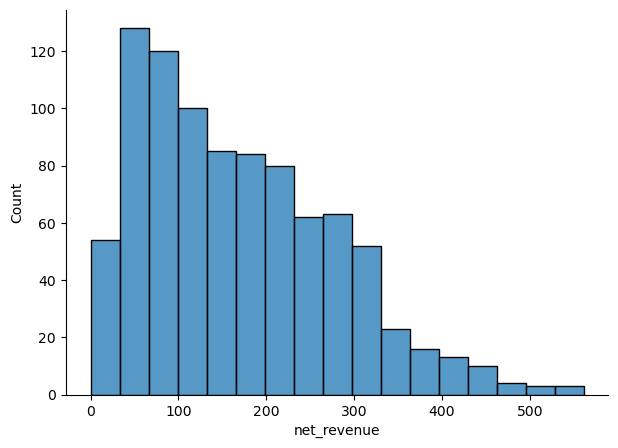

In [73]:
# Distribution of net_revenue
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(data=messy_customer_orders_df, x=messy_customer_orders_df['net_revenue'])
plt.show()

This plot is best for understanding the spread and skew of the data. The hist plot above is positively skewed (right skew). The average is higher than most data points.

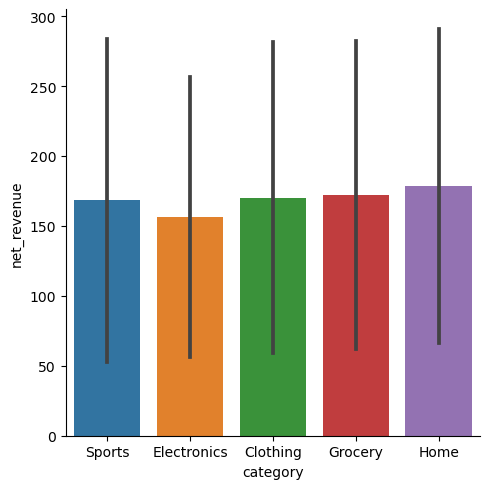

In [86]:
# Bar plot with error bars of net revenue and categories
sns.catplot(data=messy_customer_orders_df, kind="bar", x="category", y="net_revenue", errorbar="sd")
plt.show()

A bar plot with error bar is best suited for visualizing the uncertainty and variability. From the graph you can see that home has the highest net worth and electronics has the lowest net worth.

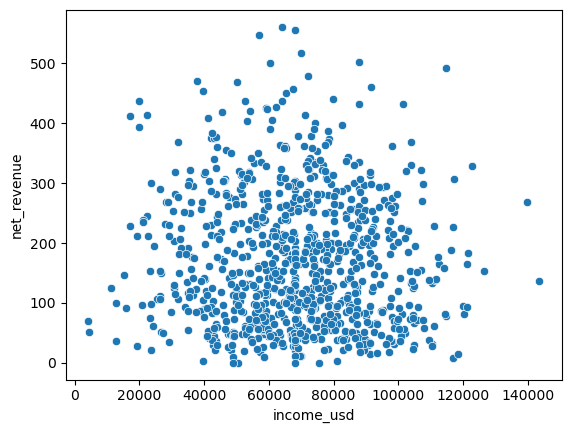

In [87]:
# Scatter plot: realationship between the net revenue and income_usd.
sns.scatterplot(data=messy_customer_orders_df, x='income_usd', y='net_revenue')
plt.show()

Scatter plot is best used to display the realationship among two numeric values (income_usd and net_revenue). There is no correlation in the plot.

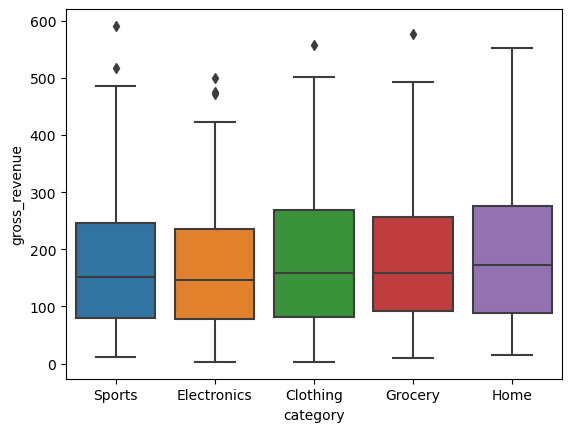

In [91]:
# Which category grossed the most/least in revenue, are their any outliers?:
sns.boxplot(data=messy_customer_orders_df, x='category', y='gross_revenue')
plt.show()

I used bar plot because I want to examine the median, quartiles, categorical distribution, and outliers. Sports had the most gross revenue by the given outlier and the home grossed in revenue. 